To gain a better understanding of the dataset, I will analyze various aspects of the data and prepare it for model training.

This section includes the following subsections:

1. **Data Understanding**

      1.1. Dataset structure

      1.2. Statistical Summary

      1.3. Find Missing Values 

2. **Exploratory Data Analysis (EDA)**

      2.1. Univariate Analysis

      2.2 Correlation Analysis

      2.3 Geographic Visualization


3. **Data Preparation**

    3.1. Data Cleaning

    3.2. Feature Engineering

    3.3. Skewness Treatment

    3.4. Encoding
    
    3.5. Feature Scaling

## Libraries

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import importlib
import src.data_utils as du

importlib.reload(du)

import numpy as np

## Extract Data

In [2]:
du.extract_data('../dataset/data.zip', '../dataset/')

## Load dataset

In [3]:
df = du.load_csv('../dataset/housing.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


<h1 align="center"><b>1. Data Understanding</b></h1>

<p align="center">
Initial exploration of the dataset structure, features, and basic statistics.
</p>

## 1. Dataset Structure

Display summary information about the dataset including column names, data types, and non-null counts.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


## 2. Initial Statistical Insights

Provide descriptive statistics of numerical features including mean, standard deviation, and value ranges.

In [5]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## 3. Missing Values

Check the dataset for missing values in each feature to identify data quality issues.

In [6]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

<h1 align="center"><b>2. Exploratory Data Analysis (EDA)</b> </h1>

<p align="center">
Comprehensive analysis of feature distributions, relationships, and data patterns to understand underlying structures in the dataset.
</p>

## 1. Univariate Analysis
Visual and statistical analysis of feature distributions to identify skewness and potential outliers.

### 1.1 Population

#### Histogram

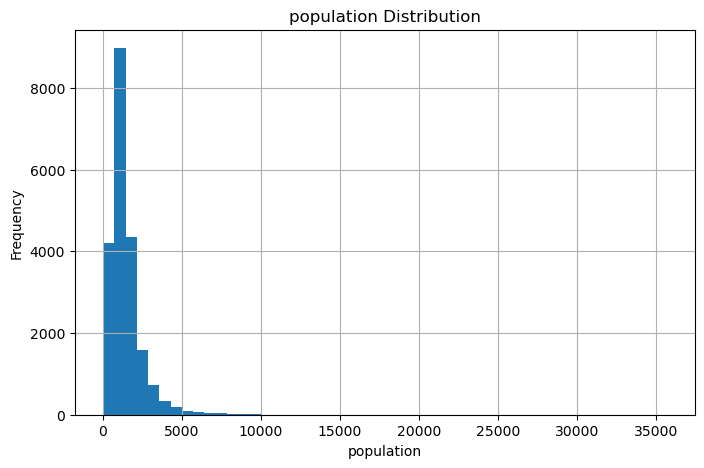

In [7]:
du.plot_histogram(df, column="population")

#### Boxplot

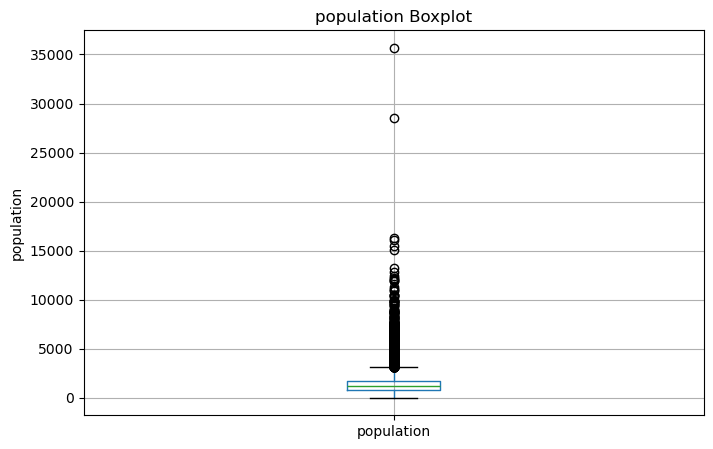

In [8]:
du.plot_boxplot(df, "population")

#### IQR

In [9]:
Q1 = df["population"].quantile(0.25)
Q3 = df["population"].quantile(0.75)
IQR = Q3 - Q1
print("Upper Bound", Q3 + 1.5 * IQR)

outliers = df[df["population"] > Q3 + 1.5 * IQR]
outliers

Upper Bound 3132.0


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
95,-122.26,37.80,36.0,5329.0,2477.0,3469.0,2323.0,2.0096,130000.0,NEAR BAY
185,-122.23,37.79,43.0,5963.0,1344.0,4367.0,1231.0,2.1917,112800.0,NEAR BAY
283,-122.16,37.79,22.0,12842.0,2048.0,4985.0,1967.0,5.9849,371000.0,NEAR BAY
460,-122.26,37.87,52.0,1087.0,371.0,3337.0,350.0,1.4012,175000.0,NEAR BAY
485,-122.26,37.86,35.0,5161.0,1744.0,3276.0,1742.0,1.6307,253600.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20543,-121.74,38.55,33.0,6861.0,1820.0,3717.0,1767.0,1.7311,182600.0,INLAND
20544,-121.76,38.55,23.0,8800.0,1857.0,6330.0,1832.0,2.0650,219400.0,INLAND
20563,-121.75,38.67,9.0,12139.0,2640.0,6837.0,2358.0,3.1250,132500.0,INLAND
20604,-121.54,39.12,17.0,4251.0,899.0,3265.0,934.0,2.3496,65000.0,INLAND


### 1.2. Total Rooms

#### Histogram

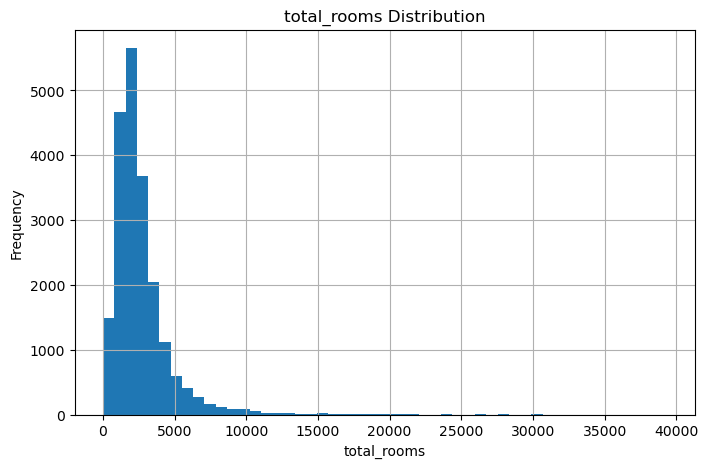

In [10]:
du.plot_histogram(df, "total_rooms")

#### Boxplot

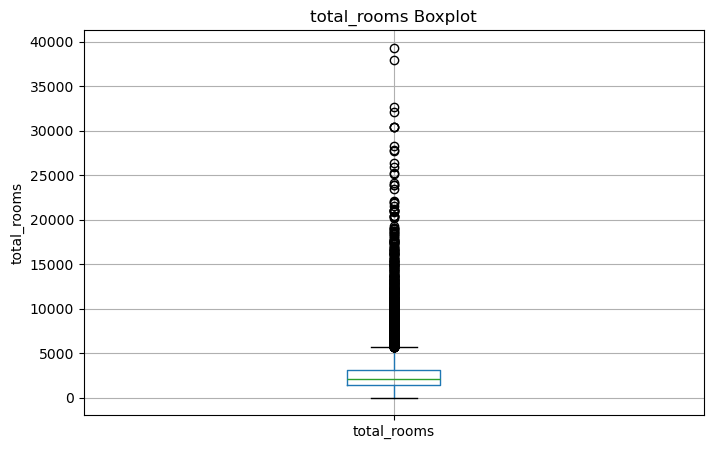

In [11]:
du.plot_boxplot(df, "total_rooms")

### 1.3. Median Income

#### Histogram

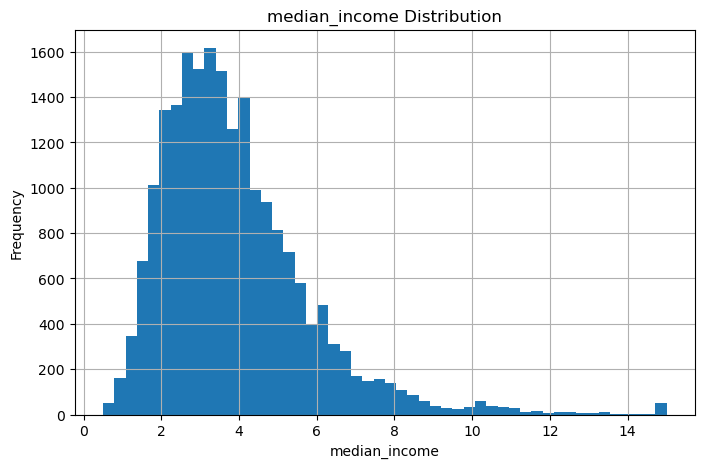

In [12]:
du.plot_histogram(df, "median_income")

#### Boxplot

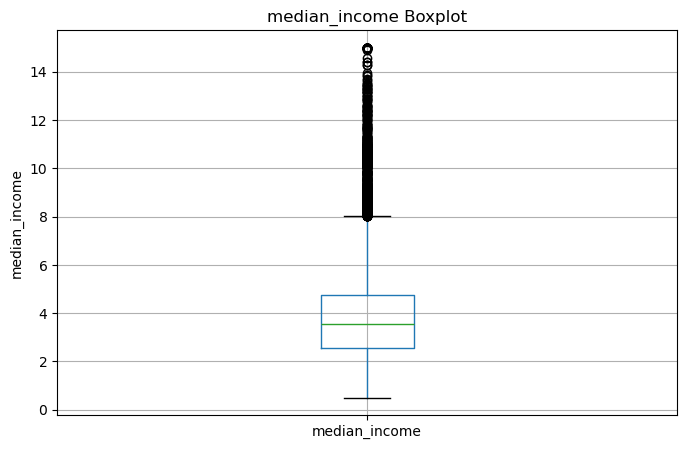

In [13]:
du.plot_boxplot(df, "median_income")

### 1.4. Other Features (Histogram & Boxplot)

#### Histograms

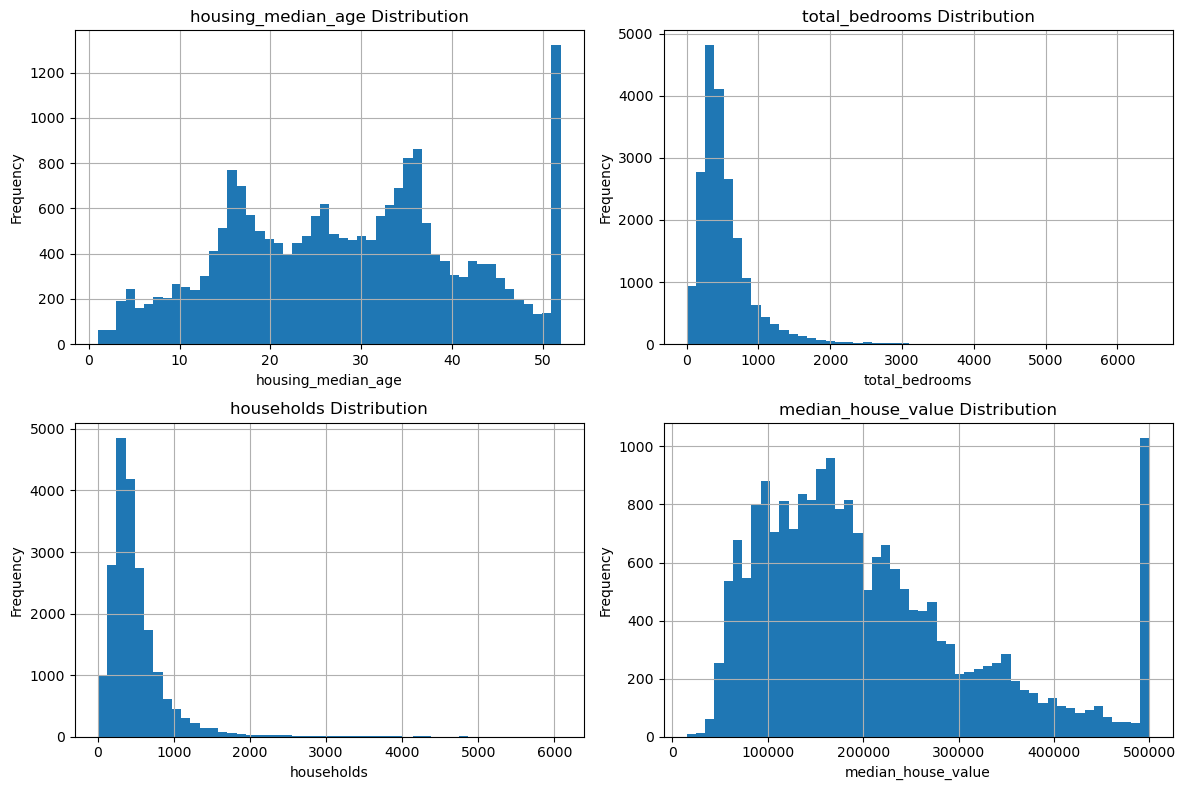

In [14]:
du.plot_multi_histograms(df, ["housing_median_age", "total_bedrooms", "households", "median_house_value"], "histograms-2.1")

#### Boxplots

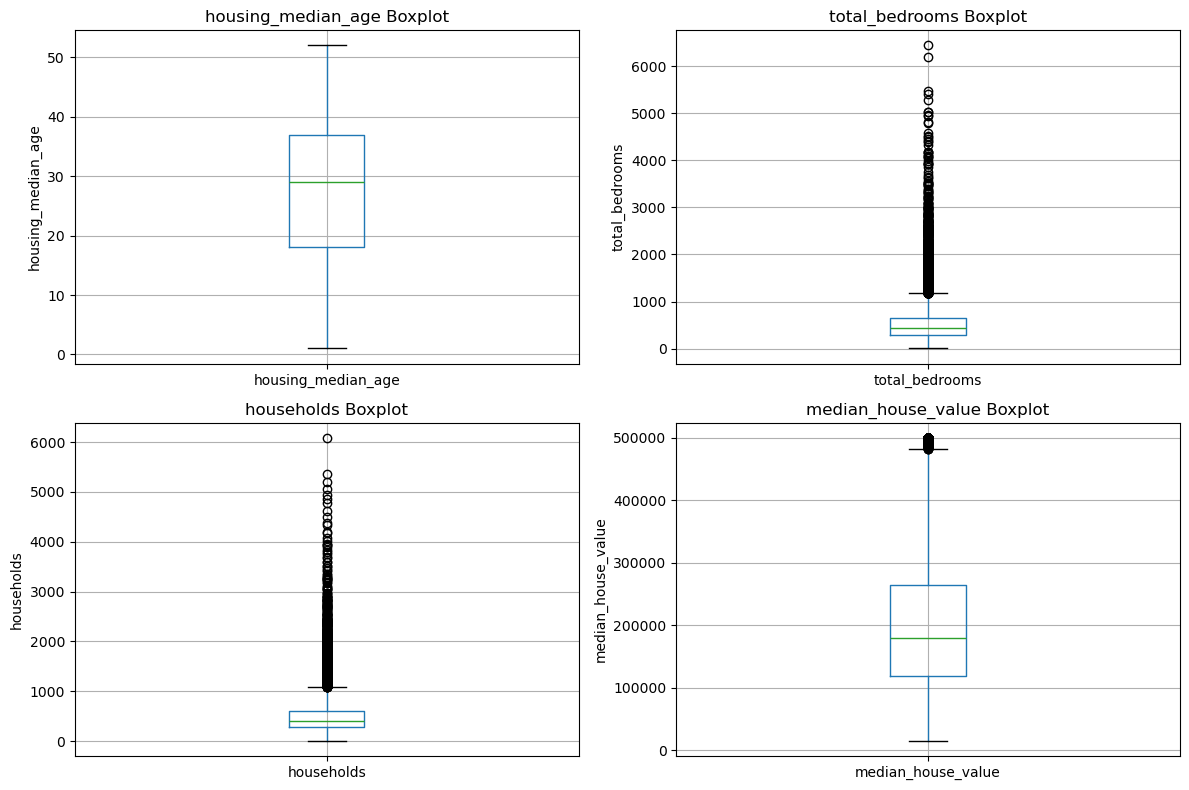

In [15]:
du.plot_multi_boxplots(df, ["housing_median_age", "total_bedrooms", "households", "median_house_value"], "Boxplots-2.1")

## 2. Correlation Analysis
To understand the relationship between features and the target variable (`median_house_value`), a correlation matrix was computed.

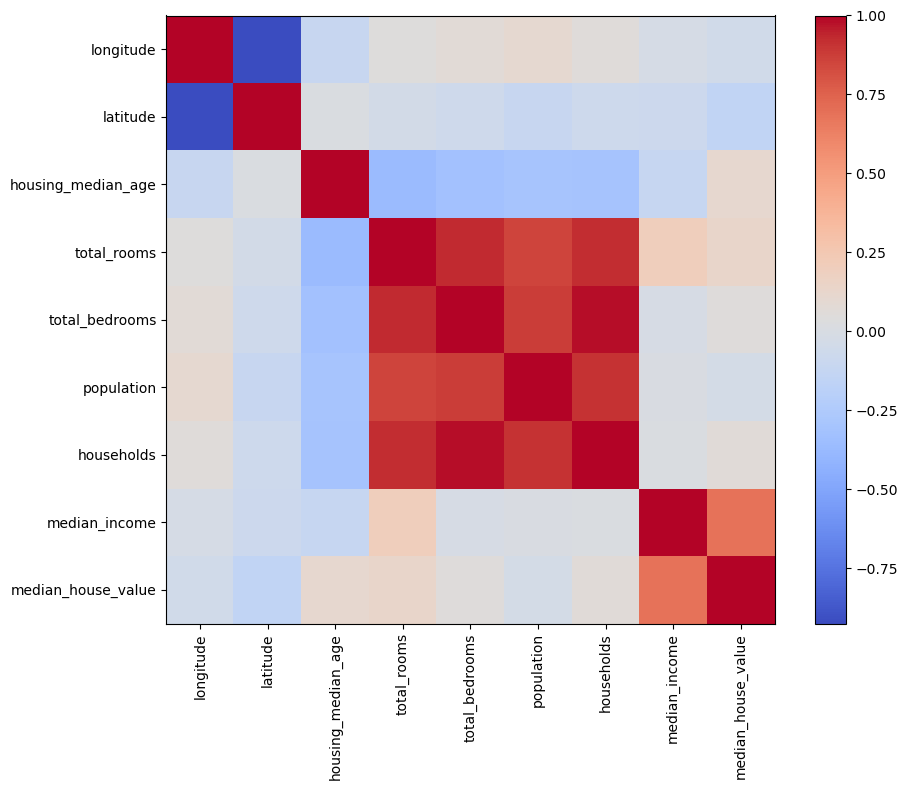

In [16]:
du.plot_correlation_heatmap(df)

In [17]:
corr_matrix = df.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

## 3. Bivariate Analysis
Scatter plots were evaluated for key features against the target variable (median_house_value) to uncover structural relationships, data collection artifacts, and to guide feature engineering for the deep learning model.

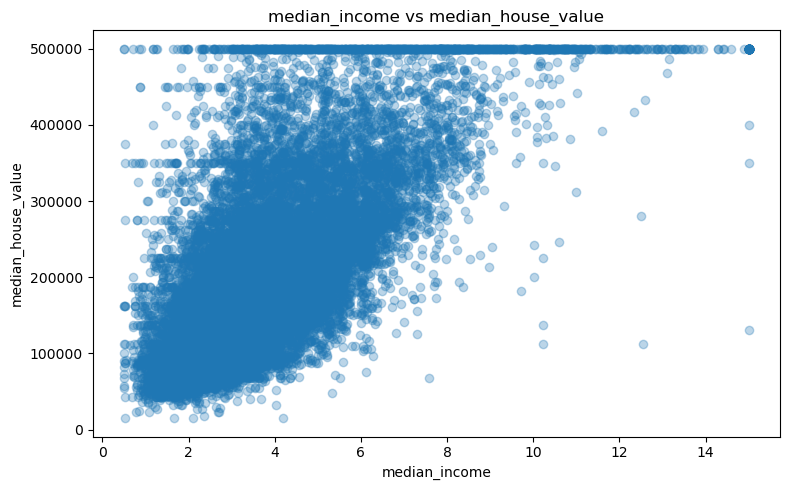

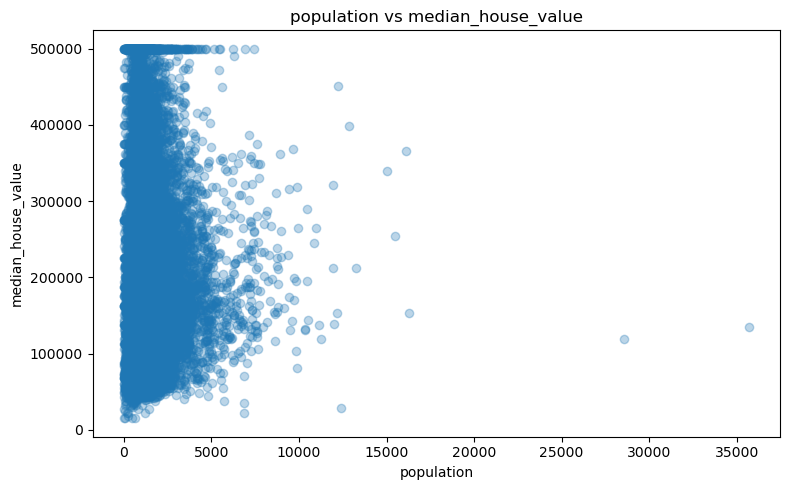

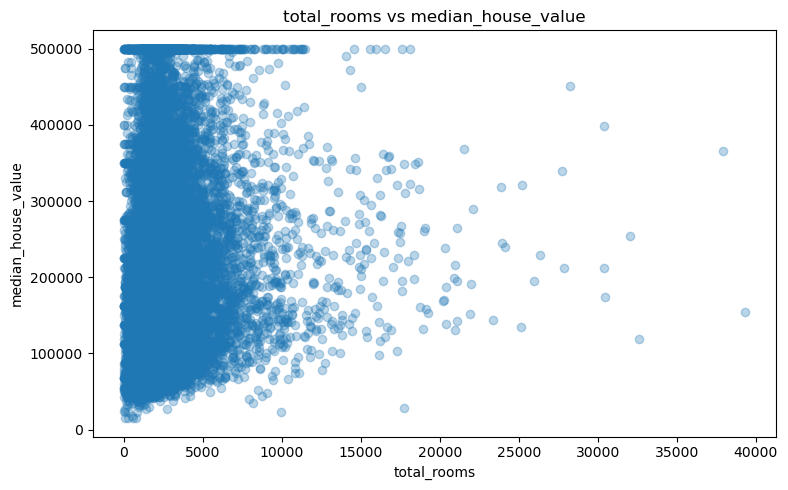

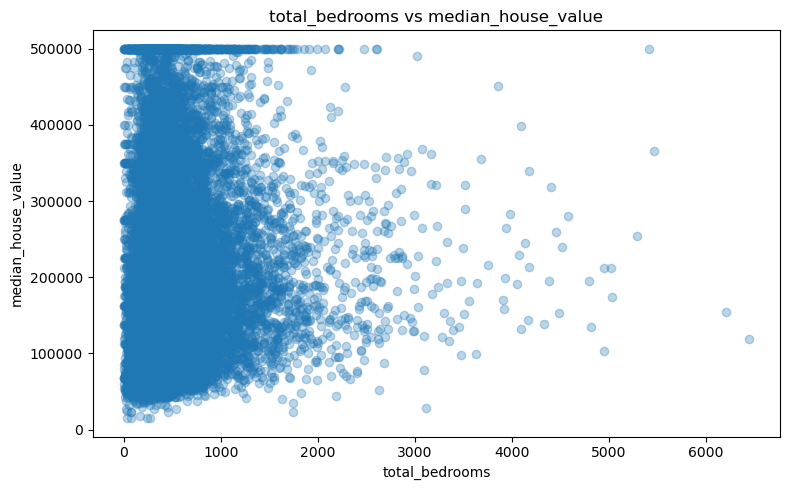

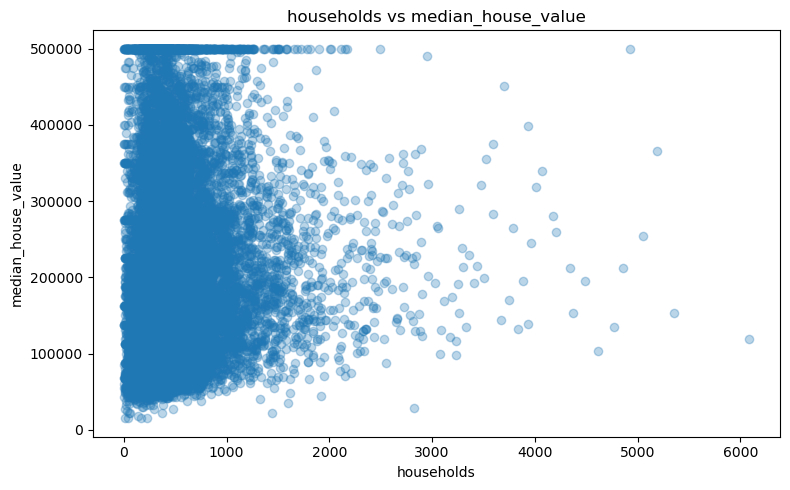

In [18]:
du.scatter_with_target(df, ["median_income", "population", "total_rooms", "total_bedrooms", "households"])

## 4. Geographic Visualization
Visual exploration of geographical patterns in the dataset using latitude and longitude to understand spatial relationships in housing prices.

### Geographic Visualization Based on Median House Value

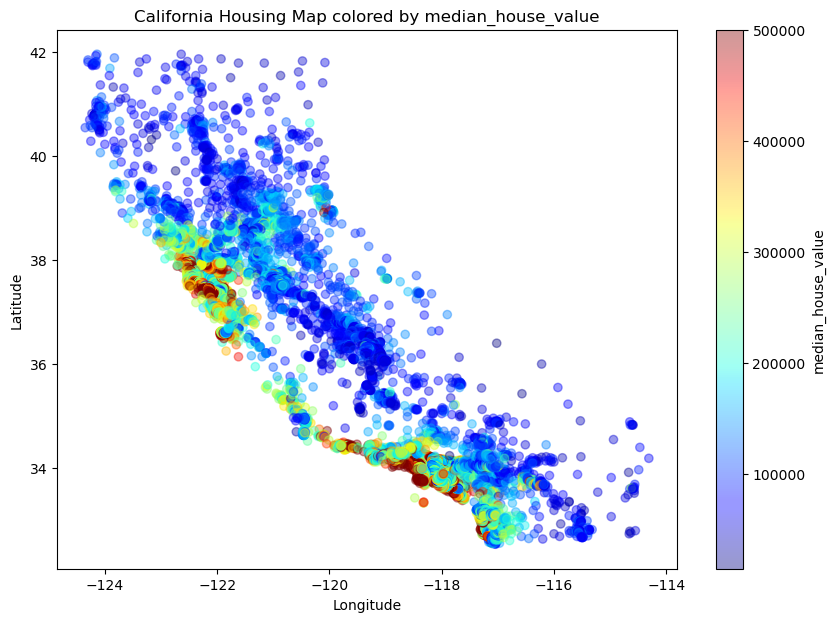

In [19]:
du.plot_housing_scatter(df, "median_house_value")

### Geographic Visualization Based on Median Income

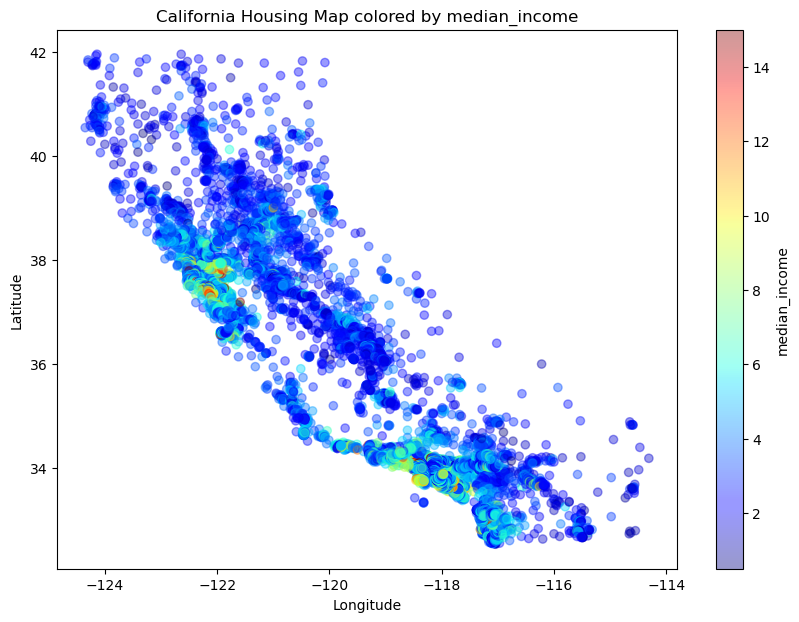

In [20]:
du.plot_housing_scatter(df, "median_income")

<h1 align="center"><b>3. Data Cleaning & Feature Engineering</b> </h1>

<p align="center">
Preparation of data for modeling by handling missing values and creating new informative features to improve predictive performance.
</p>

## 1. Data Cleaning

### 1.1. Handling Missing Values

#### Ensure that we have 207 missing values

In [21]:
df["total_bedrooms"].isnull().sum()

np.int64(207)

#### Calculate median of total_bedrooms feature

In [22]:
total_bedrooms_median = df["total_bedrooms"].median()
total_bedrooms_median

435.0

#### Replace missing values with median

In [23]:
df["total_bedrooms"] = df["total_bedrooms"].fillna(total_bedrooms_median)

#### Check the number of missing values again

In [24]:
df["total_bedrooms"].isnull().sum()

np.int64(0)

## 2. Feature Engineering

To capture more meaningful relationships within the dataset, several ratio-based features are created from the original variables.

### Rooms per Household
Create a new feature representing the average number of rooms per household.

In [31]:
df["rooms_per_household"] = df["total_rooms"] / df["households"]

### Bedrooms per Room

Create a new feature representing the proportion of bedrooms relative to total rooms.

In [32]:
df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]

### Population per Household

Create a new feature representing the average number of residents per household.

In [33]:
df["population_per_household"] = df["population"] / df["households"]

### Post Feature Engineering Analysis

After creating new ratio-based features, their distributions and relationships with the target variable were re-evaluated. This step ensures that the engineered features provide meaningful and improved representations compared to the original raw features before moving to model preparation.

#### Distribution Analysis

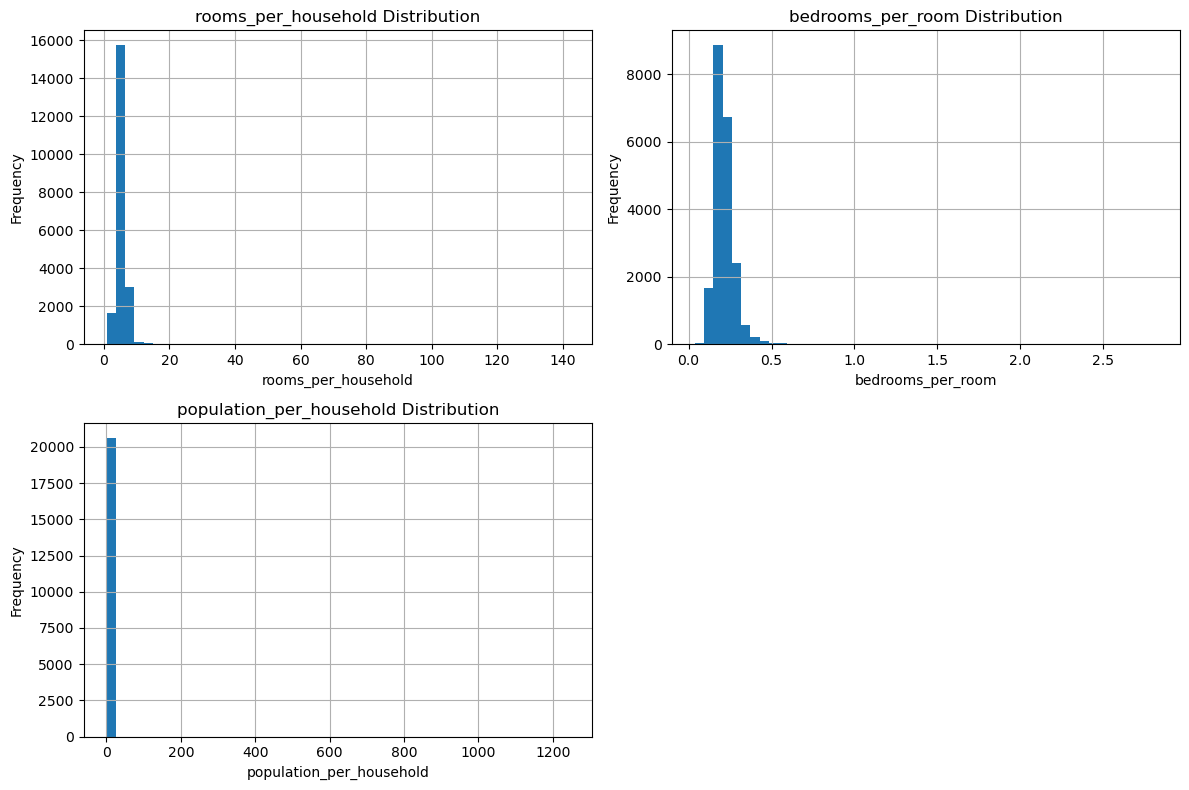

In [34]:
du.plot_multi_histograms(df, ["rooms_per_household", "bedrooms_per_room", "population_per_household"], "histograms_engineered_features")

#### Outlier Analysis

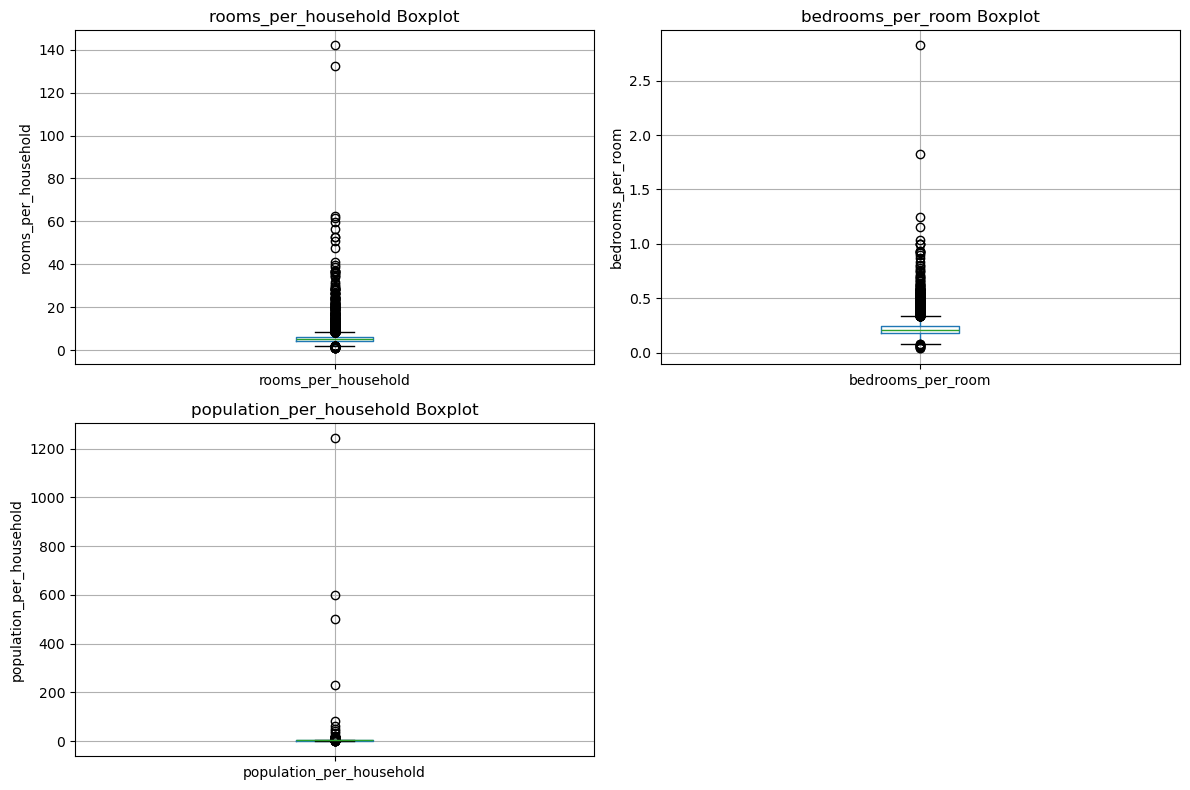

In [29]:
du.plot_multi_boxplots(df, ["rooms_per_household", "bedrooms_per_room", "population_per_household"], "boxplots_engineered_features")

#### Correlation Analysis

In [30]:
corr_matrix = df.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value          1.000000
median_income               0.688075
rooms_per_household         0.151948
total_rooms                 0.134153
housing_median_age          0.105623
households                  0.065843
total_bedrooms              0.049457
population_per_household   -0.023737
population                 -0.024650
longitude                  -0.045967
latitude                   -0.144160
bedrooms_per_room          -0.233303
Name: median_house_value, dtype: float64

## 3. Feature Transformation
For the suspected features identified in Section 2.1 and 3, I implemented a comprehensive transformation pipeline for both raw and engineered features.

### Raw Features

#### 1. Population Log Transformation

In [36]:
df["population_log"] = np.log1p(df["population"])

##### Distribution Analysis

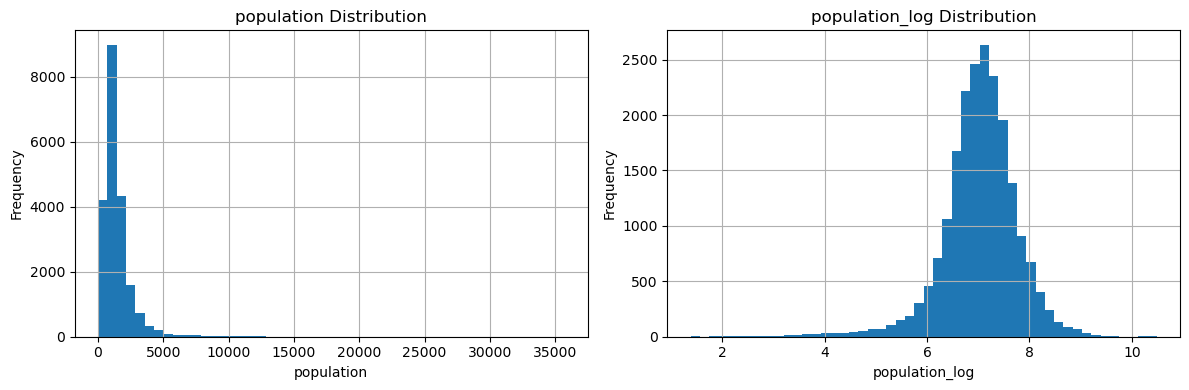

In [37]:
du.plot_multi_histograms(df, ["population", "population_log"], "histograms-population-3.1")

##### Outlier Analysis

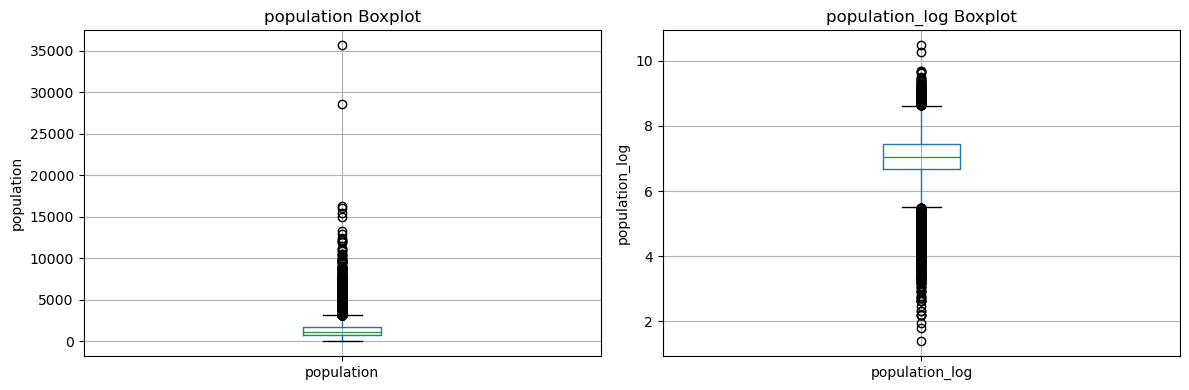

In [38]:
du.plot_multi_boxplots(df, ["population", "population_log"], "boxplots-population-3.1")

##### Correlation Analysis

In [39]:
corr = df.corr(numeric_only=True)

corr["median_house_value"][["population", "population_log"]]

population       -0.024650
population_log   -0.021205
Name: median_house_value, dtype: float64

#### 2. Total Rooms Log Transformation

In [40]:
df["total_rooms_log"] = np.log1p(df["total_rooms"])

##### Distribution Analysis

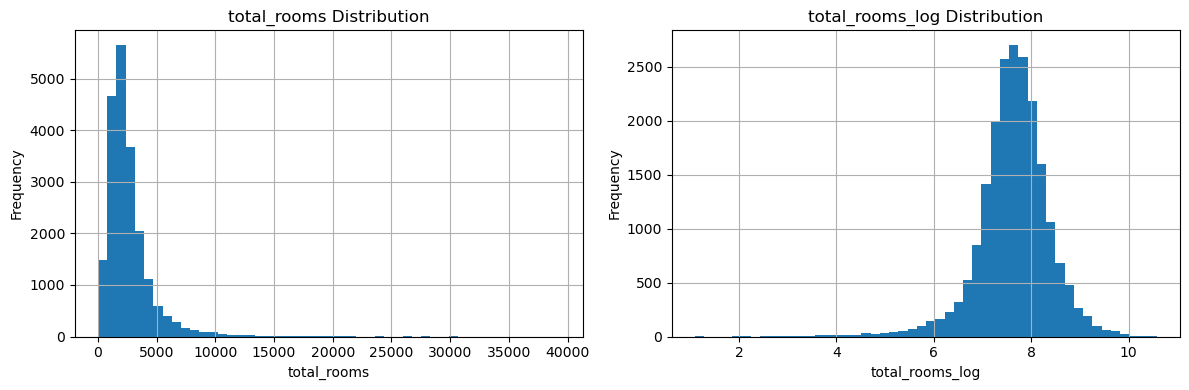

In [41]:
du.plot_multi_histograms(df, ["total_rooms", "total_rooms_log"], "histograms-total_rooms-3.1")

##### Distribution Analysis

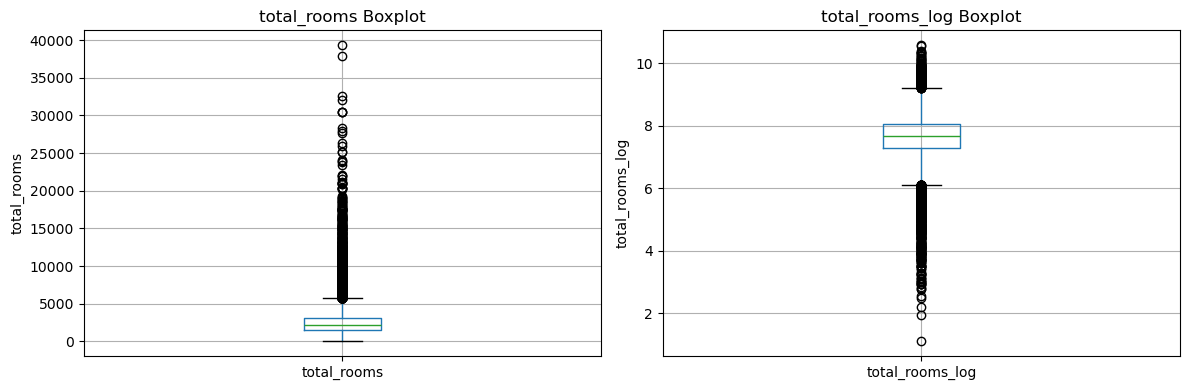

In [42]:
du.plot_multi_boxplots(df, ["total_rooms", "total_rooms_log"], "boxplots-total_rooms-3.1")

##### Correlation Analysis

In [43]:
corr = df.corr(numeric_only=True)

corr["median_house_value"][["total_rooms", "total_rooms_log"]]

total_rooms        0.134153
total_rooms_log    0.159422
Name: median_house_value, dtype: float64

#### 3. Total Bedrooms Log Transformation

In [44]:
df["total_bedrooms_log"] = np.log1p(df["total_bedrooms"])

##### Distribution Analysis

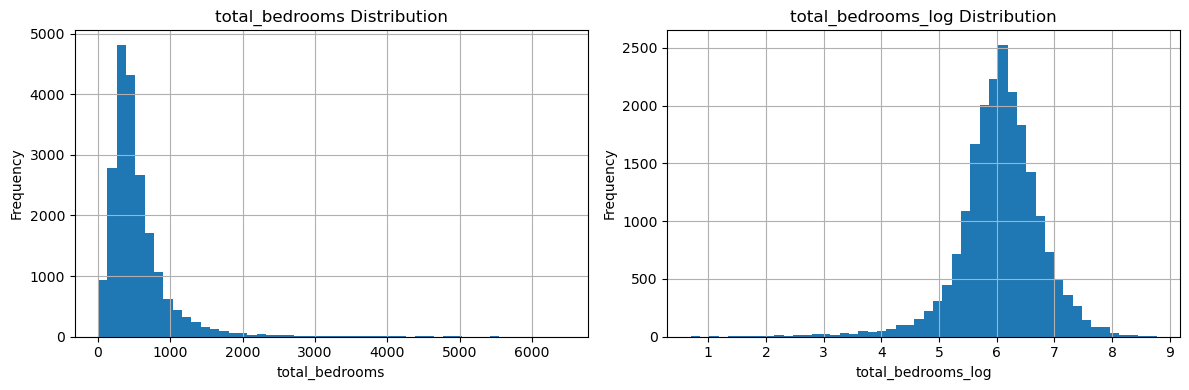

In [45]:
du.plot_multi_histograms(df, ["total_bedrooms", "total_bedrooms_log"], "histograms-total_bedrooms-3.1")

##### Outlier Analysis

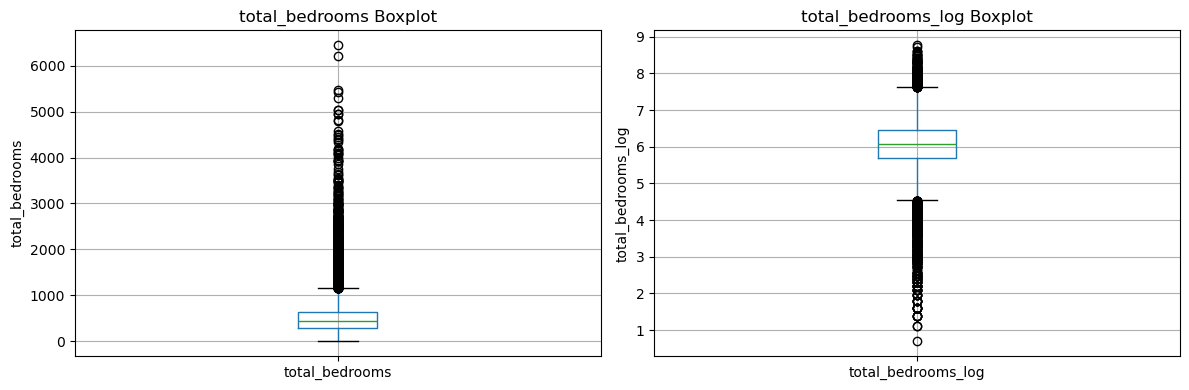

In [46]:
du.plot_multi_boxplots(df, ["total_bedrooms", "total_bedrooms_log"], "boxplots-total_bedrooms-3.1")

##### Correlation Analysis

In [47]:
corr = df.corr(numeric_only=True)

corr["median_house_value"][["total_bedrooms", "total_bedrooms_log"]]

total_bedrooms        0.049457
total_bedrooms_log    0.053059
Name: median_house_value, dtype: float64

#### 4. Households Log Transformation

In [48]:
df["households_log"] = np.log1p(df["households"])

##### Distribution Analysis

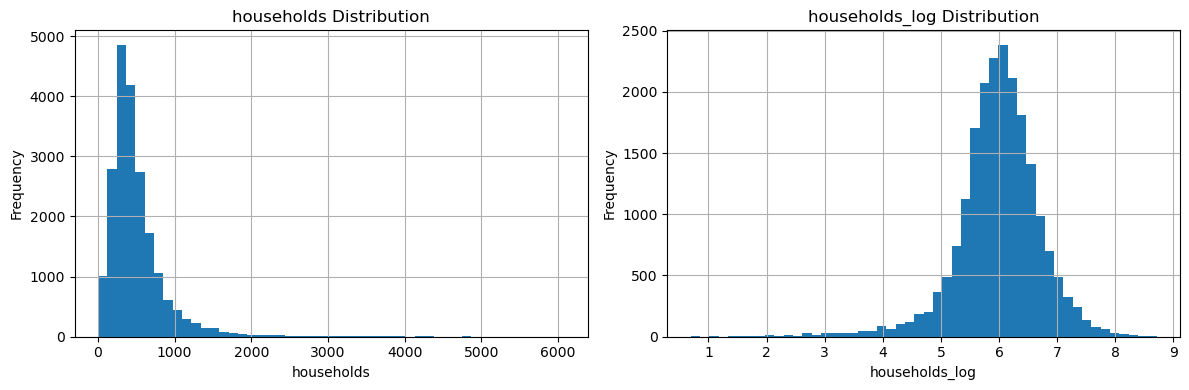

In [49]:
du.plot_multi_histograms(df, ["households", "households_log"], "histograms-households-3.1")

##### Outlier Analysis

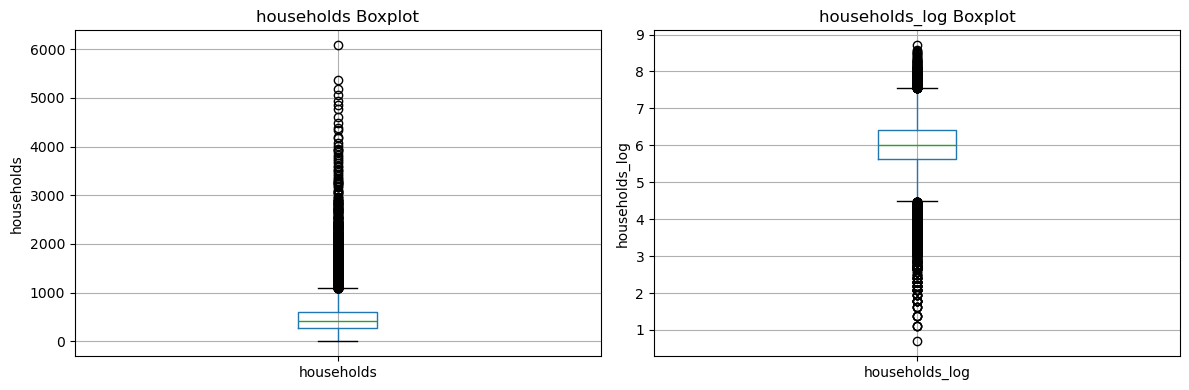

In [50]:
du.plot_multi_boxplots(df, ["households", "households_log"], "boxplots-households-3.1")

##### Correlation Analysis

In [51]:
corr = df.corr(numeric_only=True)

corr["median_house_value"][["households", "households_log"]]

households        0.065843
households_log    0.073612
Name: median_house_value, dtype: float64

### Engineered Features

#### 1. Bedrooms per Room

##### Capping

In [54]:
df['bedrooms_per_room'] = df['bedrooms_per_room'].clip(upper=1.0)

##### Distribution Analysis

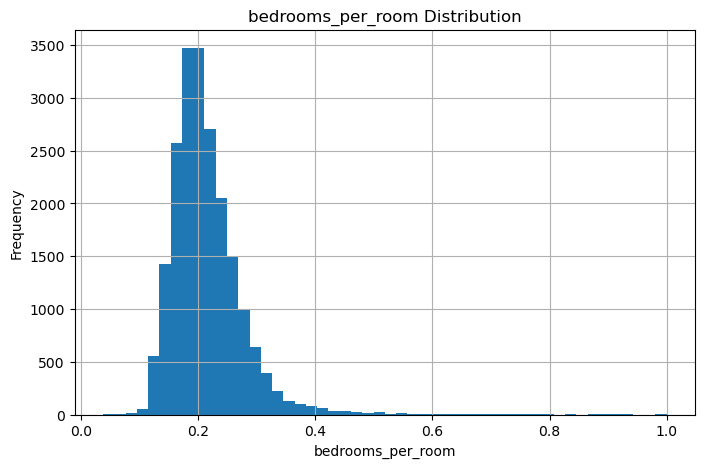

In [62]:
du.plot_histogram(df, "bedrooms_per_room")

##### Outlier Analysis

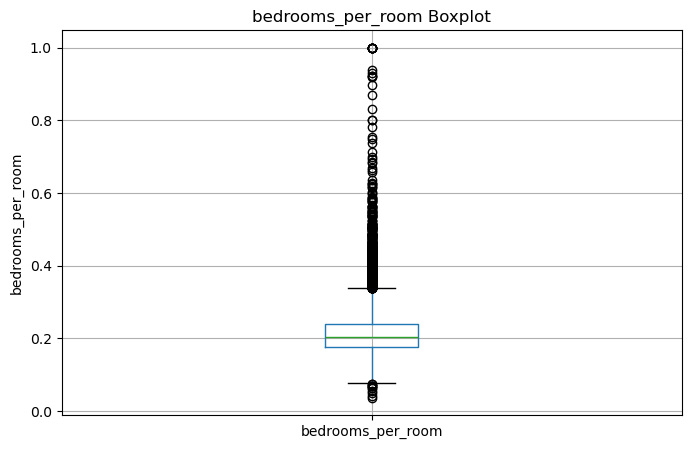

In [64]:
du.plot_boxplot(df, "bedrooms_per_room")

##### Correlation Analysis

In [66]:
corr = df.corr(numeric_only=True)

corr["median_house_value"][["bedrooms_per_room", "total_rooms", "total_bedrooms"]]

bedrooms_per_room   -0.245496
total_rooms          0.134153
total_bedrooms       0.049457
Name: median_house_value, dtype: float64

#### 2. Rooms per Household

##### Capping

In [55]:
df['rooms_per_household'] = df['rooms_per_household'].clip(upper=15.0)

##### Log Transformation

In [ ]:
df['rooms_per_household'] = np.log1p(df['rooms_per_household'])

##### Distribution Analysis

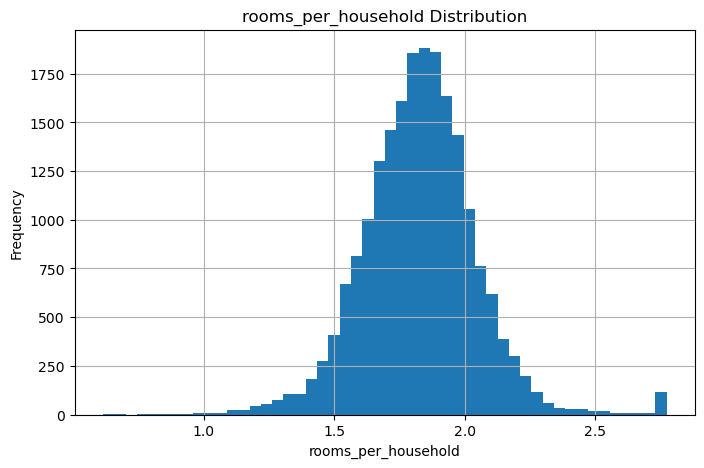

In [59]:
du.plot_histogram(df, "rooms_per_household")

##### Outlier Analysis

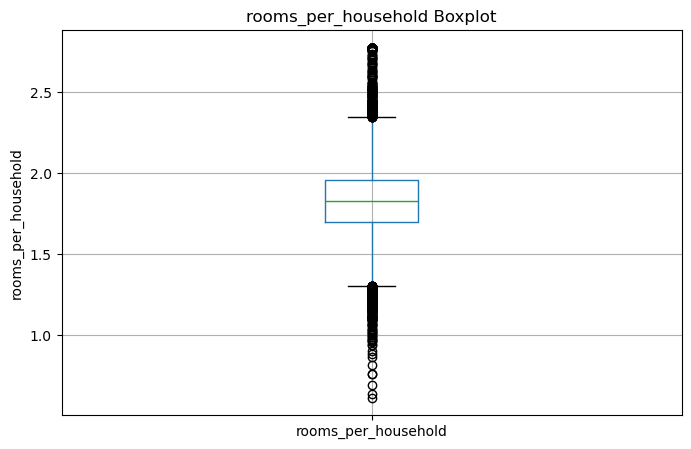

In [60]:
du.plot_boxplot(df, "rooms_per_household")

##### Correlation Analysis

In [61]:
corr = df.corr(numeric_only=True)

corr["median_house_value"][["rooms_per_household", "total_rooms", "households"]]

rooms_per_household    0.260288
total_rooms            0.134153
households             0.065843
Name: median_house_value, dtype: float64

#### 3. Population per Household

##### The 99th percentile

In [68]:
pop_99th_percentile = df['population_per_household'].quantile(0.99)

##### Capping

In [69]:
df['population_per_household'] = df['population_per_household'].clip(upper=pop_99th_percentile)

##### Log Transformation

In [70]:
df['population_per_household'] = np.log1p(df['population_per_household'])

##### Distribution Analysis

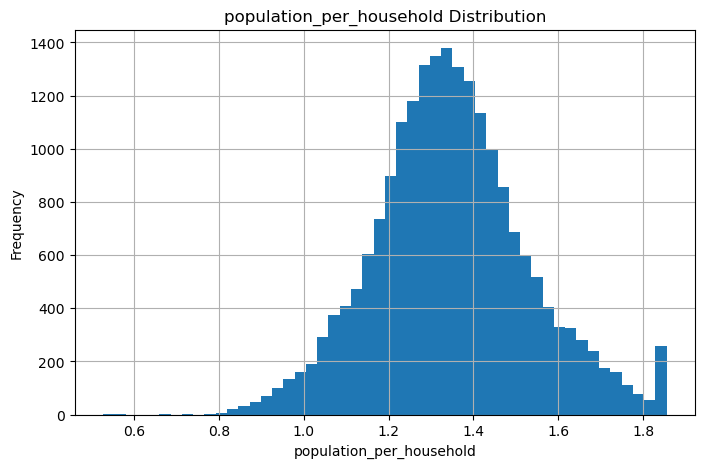

In [71]:
du.plot_histogram(df, "population_per_household")

##### Outlier Analysis

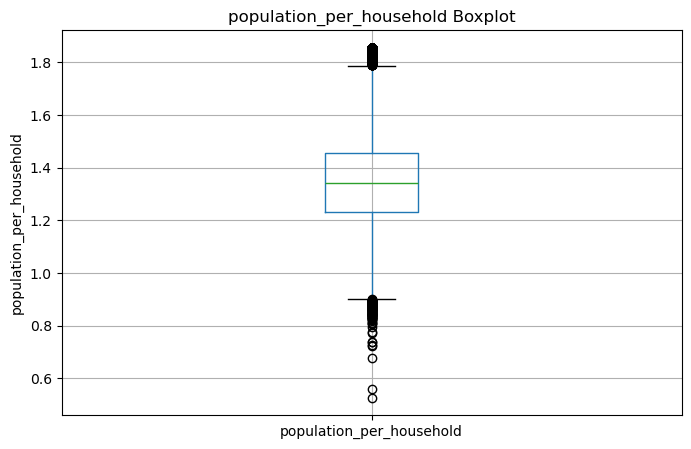

In [72]:
du.plot_boxplot(df, "population_per_household")

##### Correlation Analysis

In [74]:
corr = df.corr(numeric_only=True)

corr["median_house_value"][["population_per_household", "population", "households"]]

population_per_household   -0.277509
population                 -0.024650
households                  0.065843
Name: median_house_value, dtype: float64